# Step 2a — Percentage drop-off filter

Turn the raw walk trajectories from `02_semantic_walk.ipynb` into training sentences using a **per-anchor adaptive threshold** instead of one fixed value. For each anchor we rank the whole catalogue by Step 1 similarity, walk down that ranking, and cut at the first point where the score drops by more than `DROP_PCT` from one rank to the next — that cut score becomes the anchor's own `theta`. Then, exactly like `02a_filter_constant_theta.ipynb`, we rebuild `sentence = [anchor] + [every raw_path[i+1] whose raw_sims[i] >= theta_anchor]` and keep sentences with at least `min_sentence_length` products.

This is the supervisor's own suggested rule (a percentage drop-off between consecutive ranks, his "10% drop-off"), the lightest-weight of the adaptive candidates. The threshold decides only what gets **logged**, never where the walk went — every filter notebook reads the same `walk_raw_paths.jsonl`, so all methods are compared on identical trajectories.

**Inputs** (in `outputs/`)
- `walk_raw_paths.jsonl` — raw walks (`anchor_id`, `raw_path`, `raw_sims`, `hops_taken`)
- `walk_config.json` — the walk run this filter is built on (for traceability)
- `product_basket_freq.json` — per-product basket counts for the popularity check
- `embeddings.npy` + `product_id_to_index.json` — Step 1 vectors, used **here to compute the adaptive thresholds themselves** (not only for the rank-novelty diagnostic); `products_text.csv` for product names

**Outputs** (to `outputs/`)
- `filters/pct_dropoff/drop_0.10/thresholds.json` — per-anchor `{theta, cliff_rank, n_candidates_kept}`
- `filters/pct_dropoff/drop_0.10/walk_sentences.jsonl` — one kept sentence per line
- `filters/pct_dropoff/drop_0.10/filter_config.json` — method, drop_pct, search_window, min length, timestamps

## 1. Imports and paths

Paths are resolved relative to the project root so the notebook works regardless of where Jupyter is launched from.

In [1]:
import json
import datetime
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = ROOT / "data"
OUT_DIR = ROOT / "outputs"
STEP1_DIR = OUT_DIR / "step1"

print("Data dir:   ", DATA_DIR)
print("Outputs dir:", OUT_DIR)

Data dir:    /Users/linnhtet/Developer/bachelor-thesis/data
Outputs dir: /Users/linnhtet/Developer/bachelor-thesis/outputs


## 2. Parameters

The adaptive rule is defined by two named constants (kept here, not buried inline, so they are easy to sweep later). Unlike the constant-theta method there is no single `theta` — each anchor gets its own, computed in §4.

In [2]:
METHOD_NAME = "pct_dropoff"
VALUE_LABEL = "drop_0.10"
FILTER_DIR = OUT_DIR / "filters" / METHOD_NAME / VALUE_LABEL
FILTER_DIR.mkdir(parents=True, exist_ok=True)

# ---- Adaptive threshold rule ----
DROP_PCT = 0.10        # a relative drop >= this between consecutive ranked scores marks the cliff
                       # (Dr. Miller's suggested 10% figure; not yet validated)
SEARCH_WINDOW = 50     # how deep into each anchor's FULL ranking the drop search looks.
                       # This bounds only the search, NOT what §4 Step 1 computes — the ranking
                       # itself is never truncated (an earlier top-2000 truncation faked bends).

min_sentence_length = 2    # discard sentences shorter than this (same rule as constant_theta)

# The fixed baseline this adaptive method is compared against (constant_theta's value).
CONSTANT_THETA_BASELINE = 0.70

# Stress-test anchors — must match those 02_semantic_walk.ipynb always walked.
STRESS_TEST_IDS = {
    4210:  "Whole Milk",
    6347:  "Unsweetened Almond Milk",
    651:   "Organic Salted Butter",
    16268: "Vegan Butter",
    6104:  "Whole Milk Plain Yogurt",
    920:   "Coconut Yogurt",
}

## 3. Load the raw walks and supporting artifacts

Everything this notebook needs was produced upstream: the raw walks and walk config from `02_semantic_walk.ipynb`, the per-product basket counts (so the popularity check never rebuilds the basket graph), and Step 1's embeddings + id map — used **both** to compute the per-anchor thresholds (§4) and for the rank novelty test.

In [3]:
# Raw walks from the walk notebook (one JSON object per line).
raw_walks = []
with open(OUT_DIR / "walk_raw_paths.jsonl") as f:
    for line in f:
        raw_walks.append(json.loads(line))

# The walk run this filter is built on — its timestamp is recorded for traceability.
with open(OUT_DIR / "walk_config.json") as f:
    walk_config = json.load(f)

# Per-product sampled-basket counts (for the background popularity check).
with open(OUT_DIR / "product_basket_freq.json") as f:
    freq = json.load(f)
total_baskets = freq["total_baskets"]
product_basket_count = {int(pid): c for pid, c in freq["product_basket_count"].items()}

# Step 1 artifacts: embeddings (unit-normalised) + id map for both the threshold
# computation and the rank novelty test, and product names for readable output.
embeddings = np.load(STEP1_DIR / "embeddings.npy").astype(np.float32)
norms = np.linalg.norm(embeddings, axis=1, keepdims=True)
embeddings = embeddings / np.clip(norms, 1e-12, None)

with open(STEP1_DIR / "product_id_to_index.json") as f:
    pid_to_idx = {int(pid): row for pid, row in json.load(f).items()}

products_text = pd.read_csv(STEP1_DIR / "products_text.csv")
id_to_name = dict(zip(products_text["product_id"], products_text["product_name"]))


def name(pid):
    return id_to_name.get(int(pid), f"?{pid}")


def names(ids):
    return [name(p) for p in ids]


print(f"raw walks loaded      : {len(raw_walks):,}")
print(f"walk_config timestamp : {walk_config.get('timestamp')}")
print(f"basket counts         : {len(product_basket_count):,} products, "
      f"{total_baskets:,} total baskets")
print(f"embeddings            : {embeddings.shape}")

raw walks loaded      : 400,100
walk_config timestamp : 2026-08-08T14:06:21
basket counts         : 48,526 products, 1,000,000 total baskets
embeddings            : (49688, 384)


## 4. Rank each anchor and compute its per-anchor theta

Two steps, per anchor:

**Rank (Step 1).** Cosine-similarity the anchor against the whole catalogue (one `anchor_vec @ embeddings` matrix-vector product), mask the anchor's own index to `-inf` *before* sorting (its self-similarity is 1.0 and would otherwise read as a guaranteed rank-1 cliff every time), and sort descending. The ranking is kept **full** — only the drop search below decides how deep to look. (An earlier elbow attempt truncated to the top 2000 and manufactured fake bends; never truncating the ranking itself avoids repeating that.)

**Threshold (Step 2).** Walk the first `SEARCH_WINDOW` ranks computing the relative drop `(s_i - s_{i+1}) / s_i` (ranks are 1-based here, rank 1 = the top neighbour). At the first drop `>= DROP_PCT`, cut: rank *i* is the last kept and its score becomes `theta`. If no drop clears the bar within the window, keep the whole window (graceful fallback, no cut). We compute this only for anchors that actually appear in `walk_raw_paths.jsonl` — starting products with no baskets were never walked, so there is nothing to threshold for them.

Saved to `filters/pct_dropoff/drop_0.10/thresholds.json`, which on its own shows how much `theta` varies from anchor to anchor — the whole point of an adaptive rule.

In [4]:
def anchor_sorted_sims(anchor_id):
    """Full descending similarity of the whole catalogue to this anchor.

    Mask the anchor's own row to -inf BEFORE sorting: its self-similarity is 1.0
    and, left in, would look like a guaranteed rank-1 cliff for every anchor. The
    ranking is kept FULL (never truncated) — only the drop search bounds depth.
    """
    a = pid_to_idx[anchor_id]
    sims = embeddings @ embeddings[a]      # cosine vs anchor (unit-norm); fresh array
    sims[a] = -np.inf                      # mask self before sorting, not after
    return np.sort(sims)[::-1]             # descending; sorted_sims[0] = rank 1


def pct_dropoff_theta(sorted_sims):
    """Percentage drop-off threshold for one anchor's full ranking (ranks 1-based).

    Walk the first SEARCH_WINDOW entries; at the first consecutive pair whose
    relative drop >= DROP_PCT, cut there (that rank is the last kept). If nothing
    clears the drop within the window, keep the whole window (graceful fallback).
    """
    window = min(SEARCH_WINDOW, len(sorted_sims))
    for i in range(1, window):                     # rank i in 1 .. window-1
        s_i = float(sorted_sims[i - 1])            # score at rank i
        s_next = float(sorted_sims[i])             # score at rank i+1
        if s_i <= 0:                               # degenerate tail; stop searching
            break
        if (s_i - s_next) / s_i >= DROP_PCT:
            return {"theta": s_i, "cliff_rank": i, "n_candidates_kept": i}
    # Fallback: no qualifying drop within the window -> keep the full window.
    return {"theta": float(sorted_sims[window - 1]),
            "cliff_rank": None, "n_candidates_kept": window}


# Only anchors that were actually walked (not the full starting_products list).
walked_anchor_ids = sorted({int(w["anchor_id"]) for w in raw_walks})

try:
    from tqdm.auto import tqdm
    anchor_iter = tqdm(walked_anchor_ids, desc="anchors")
except ImportError:
    anchor_iter = walked_anchor_ids

anchor_thresholds = {}   # anchor_id -> {"theta", "cliff_rank", "n_candidates_kept"}
n_skipped = 0
for aid in anchor_iter:
    if aid not in pid_to_idx:
        n_skipped += 1                   # not in the Step 1 catalogue -> cannot rank
        continue
    anchor_thresholds[aid] = pct_dropoff_theta(anchor_sorted_sims(aid))

# Convenience map for the filter step.
anchor_theta = {aid: t["theta"] for aid, t in anchor_thresholds.items()}

n_cliff = sum(1 for t in anchor_thresholds.values() if t["cliff_rank"] is not None)
n_fallback = len(anchor_thresholds) - n_cliff
thetas_all = np.array([t["theta"] for t in anchor_thresholds.values()])
print(f"walked anchors           : {len(walked_anchor_ids):,}")
print(f"thresholds computed      : {len(anchor_thresholds):,}")
if n_skipped:
    print(f"skipped (not in catalog) : {n_skipped:,}")
print(f"found a cliff            : {n_cliff:,} "
      f"({100 * n_cliff / max(len(anchor_thresholds), 1):.1f}%)")
print(f"hit window fallback      : {n_fallback:,} "
      f"({100 * n_fallback / max(len(anchor_thresholds), 1):.1f}%)")
if len(thetas_all):
    print(f"theta mean/median/min/max: {thetas_all.mean():.3f} / "
          f"{np.median(thetas_all):.3f} / {thetas_all.min():.3f} / {thetas_all.max():.3f}")

# Save the per-anchor thresholds (useful on its own, independent of filtering below).
thresholds_path = FILTER_DIR / "thresholds.json"
with open(thresholds_path, "w") as f:
    json.dump({str(aid): t for aid, t in anchor_thresholds.items()}, f)
print("Saved", thresholds_path.name)

/Users/linnhtet/Developer/bachelor-thesis/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
anchors: 100%|████████████████████████████| 20005/20005 [00:40<00:00, 490.34it/s]


walked anchors           : 20,005
thresholds computed      : 20,005
found a cliff            : 1,702 (8.5%)
hit window fallback      : 18,303 (91.5%)
theta mean/median/min/max: 0.748 / 0.751 / 0.267 / 1.000
Saved pct_dropoff_thresholds.json


## 5. Apply the per-anchor drop-off filter

Same mechanism as the constant-theta notebook, except each walk is filtered against **its own anchor's** `theta` from §4 rather than one global value. Since `raw_sims[i]` is the similarity for `raw_path[i + 1]`, this is a direct zip of `raw_path[1:]` against `raw_sims`. Keep only sentences with `>= min_sentence_length` products.

In [5]:
def filter_walk(w, theta):
    """Rebuild a sentence from a raw walk: anchor + every winner with raw_sim >= theta."""
    sentence = [w["anchor_id"]]
    for nxt, sim in zip(w["raw_path"][1:], w["raw_sims"]):
        if sim >= theta:
            sentence.append(nxt)
    return sentence


filtered = []          # {"anchor_id", "raw_path", "sentence", "hops_taken"} for every filtered walk
kept_sentences = []    # {"anchor_id", "sentence"} for the kept ones only
n_total = 0
n_discarded = 0
n_no_theta = 0

for w in raw_walks:
    aid = w["anchor_id"]
    theta = anchor_theta.get(aid)
    if theta is None:                    # anchor had no computable threshold (skipped in §4)
        n_no_theta += 1
        continue
    n_total += 1
    sentence = filter_walk(w, theta)     # this walk's own anchor threshold
    filtered.append({
        "anchor_id": aid,
        "raw_path": w["raw_path"],
        "sentence": sentence,
        "hops_taken": w["hops_taken"],
    })
    if len(sentence) >= min_sentence_length:
        kept_sentences.append({"anchor_id": aid, "sentence": sentence})
    else:
        n_discarded += 1

print(f"walks processed  : {n_total:,}")
print(f"sentences kept   : {len(kept_sentences):,}")
print(f"discarded (short): {n_discarded:,} ({100 * n_discarded / max(n_total, 1):.1f}%)")
if n_no_theta:
    print(f"walks skipped (anchor had no threshold): {n_no_theta:,}")

walks processed  : 400,100
sentences kept   : 75,605
discarded (short): 324,495 (81.1%)


## 6. Save outputs

The kept sentences plus a filter-config sidecar. There is no single `theta` to record — the method is defined by `drop_pct` + `search_window`, and the actual per-anchor thresholds live in `filters/pct_dropoff/drop_0.10/thresholds.json` from §4. The config records the timestamp of the `walk_config.json` this corpus was built from, so a sentence file is always traceable back to both the filter run and the walk run.

In [6]:
# 1) Kept sentences.
sent_path = FILTER_DIR / "walk_sentences.jsonl"
with open(sent_path, "w") as f:
    for s in kept_sentences:
        f.write(json.dumps(s) + "\n")

# 2) Filter configuration (+ provenance back to the walk run).
filter_config = {
    "method": METHOD_NAME,
    "drop_pct": DROP_PCT,
    "search_window": SEARCH_WINDOW,
    "min_sentence_length": min_sentence_length,
    "n_raw_walks": len(raw_walks),
    "n_anchors_thresholded": len(anchor_thresholds),
    "n_sentences_kept": len(kept_sentences),
    "source_walk_config_timestamp": walk_config.get("timestamp"),
    "timestamp": datetime.datetime.now().isoformat(timespec="seconds"),
}
cfg_path = FILTER_DIR / "filter_config.json"
with open(cfg_path, "w") as f:
    json.dump(filter_config, f, indent=2)

print("Saved", sent_path.name, "and", cfg_path.name)
print(json.dumps(filter_config, indent=2))

Saved walk_sentences__pct_dropoff.jsonl and filter_config__pct_dropoff.json
{
  "method": "pct_dropoff",
  "drop_pct": 0.1,
  "search_window": 50,
  "min_sentence_length": 2,
  "n_raw_walks": 400100,
  "n_anchors_thresholded": 20005,
  "n_sentences_kept": 75605,
  "source_walk_config_timestamp": "2026-08-08T14:06:21",
  "timestamp": "2026-08-08T15:36:15"
}


## 7. Validation — sentence lengths and discard rate

The filter-dependent checks: how long the kept sentences are, and what fraction of walks were discarded for falling short of `min_sentence_length`.

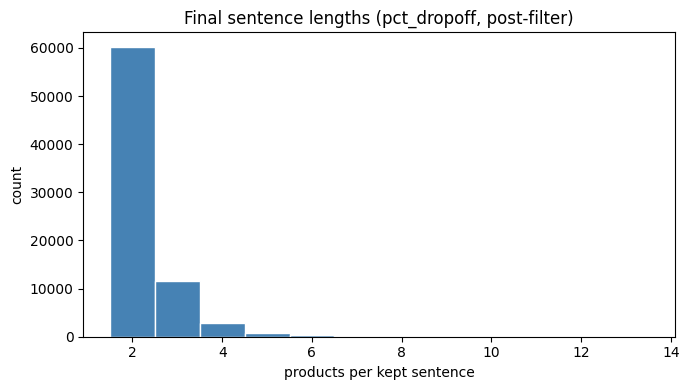

sentences kept   : 75,605
discarded (short): 324,495/400,100 (81.1%)
sentence length mean/median/max: 2.28 / 2 / 13


In [7]:
sent_lengths = [len(s["sentence"]) for s in kept_sentences]

fig, ax = plt.subplots(figsize=(7, 4))
if sent_lengths:
    ax.hist(sent_lengths, bins=range(min_sentence_length, max(sent_lengths) + 2),
            align="left", color="steelblue", edgecolor="white")
ax.set_title("Final sentence lengths (pct_dropoff, post-filter)")
ax.set_xlabel("products per kept sentence"); ax.set_ylabel("count")
plt.tight_layout(); plt.show()

print(f"sentences kept   : {len(kept_sentences):,}")
print(f"discarded (short): {n_discarded:,}/{n_total:,} "
      f"({100 * n_discarded / max(n_total, 1):.1f}%)")
if sent_lengths:
    print(f"sentence length mean/median/max: "
          f"{np.mean(sent_lengths):.2f} / {int(np.median(sent_lengths))} / {max(sent_lengths)}")

### Example walks

A handful of full walks for manual inspection: anchor, the raw path (every bridge the walk crossed), and the sentence the filter kept from it.

In [8]:
kept_filtered = [x for x in filtered if len(x["sentence"]) >= min_sentence_length]
display_rng = np.random.default_rng(0)
picks = (display_rng.choice(len(kept_filtered),
                            size=min(10, len(kept_filtered)), replace=False)
         if kept_filtered else [])

for i in picks:
    x = kept_filtered[int(i)]
    print("anchor   :", name(x["anchor_id"]))
    print("raw path :", " -> ".join(names(x["raw_path"])))
    print("sentence :", " -> ".join(names(x["sentence"])))
    print("hops     :", x["hops_taken"])
    print("-" * 90)

anchor   : Clean Linen Candle
raw path : Clean Linen Candle -> Clean Linen Solid Air Freshener -> Eez-Thru Icy Mint Flossers -> Fancy Greens -> Egg Salad -> Organic Hearts Of Palm -> Tortilla Chips, Clasico, Jalapeno Lime -> Multivitamin, Kids Complete, Gummies -> Vanilla Bean Ice Cream -> Original Thin Rye Crispbread -> Organic Plain Whole Milk Yogurt -> Organic Broccoli Crowns -> Organic Orange Bell Pepper -> Large Lemon -> Mint -> Natural Vanilla Marshmallows
sentence : Clean Linen Candle -> Clean Linen Solid Air Freshener
hops     : 15
------------------------------------------------------------------------------------------
anchor   : Vitamin D Milk
raw path : Vitamin D Milk -> Sea Salt Pita Chips -> Vanilla Almond Breeze Almond Milk -> Squeeze Pouch Sour Cream -> Thin & Crispy Crust Four Cheese Pizza -> Cola -> Organic Russet Potato -> Organic Egg Whites -> Air Chilled Organic Boneless Skinless Chicken Breasts -> Extra Virgin Olive Oil -> Salted Tub of Butter -> Original Hummus -

## 8. Rank novelty — does the filter surface *new* substitutes?

For each stress-test anchor, look at every product its kept sentences surfaced and find where that product sits in Step 1's own full similarity ranking for the anchor (rank 1 = Step 1's nearest neighbour). Anything inside Step 1's top-10 is flagged "not new" — the walk + filter earns its keep only when it surfaces genuine substitutes ranked *far down* that list.

In [9]:
surfaced = {pid: Counter() for pid in STRESS_TEST_IDS}
for s in kept_sentences:
    a = s["anchor_id"]
    if a in surfaced:
        for p in s["sentence"]:
            if p != a:
                surfaced[a][p] += 1

# Compute each anchor's full similarity vector + rank lookup ONCE, then reuse it
# across all of that anchor's surfaced targets (instead of re-ranking per target).
print("Rank novelty: where do the filter's discoveries sit in Step 1's own ranking?")
print("=" * 70)
for pid, nm in STRESS_TEST_IDS.items():
    if pid not in pid_to_idx:
        print(f"\n{nm} ({pid}) — not in catalogue, skipped")
        continue
    sims = embeddings @ embeddings[pid_to_idx[pid]]        # cosine vs anchor (unit-norm)
    ranks = np.empty(len(sims), dtype=int)
    ranks[np.argsort(-sims)] = np.arange(len(sims))        # rank[idx]: 0 = anchor, 1 = #1 neighbour
    print(f"\n{nm} ({pid})")
    surfaced_here = surfaced.get(pid, Counter())
    if not surfaced_here:
        print("  (no substitutes surfaced)")
    for p, c in surfaced_here.most_common():
        idx = pid_to_idx[p]
        rank = int(ranks[idx])
        flag = "  <- inside Step 1's own top-10, not new" if rank <= 10 else ""
        print(f"  {c}x  {name(p):<45} rank={rank:>6}  sim={sims[idx]:.3f}{flag}")

Rank novelty: where do the filter's discoveries sit in Step 1's own ranking?

Whole Milk (4210)
  8x  Organic Whole Milk                            rank=     6  sim=0.892  <- inside Step 1's own top-10, not new
  3x  Organic Milk                                  rank=    22  sim=0.834
  3x  Fat Free Milk                                 rank=    29  sim=0.825
  2x  Chocolate Lowfat Milk                         rank=    31  sim=0.823
  1x  Chocolate Milk                                rank=     9  sim=0.869  <- inside Step 1's own top-10, not new
  1x  Lowfat Milk                                   rank=    28  sim=0.827

Unsweetened Almond Milk (6347)
  6x  Organic Unsweetened Almond Milk               rank=     7  sim=0.962  <- inside Step 1's own top-10, not new
  5x  Unsweetened Almondmilk                        rank=     1  sim=0.982  <- inside Step 1's own top-10, not new
  1x  Organic Unsweetened Original Non Dairy Almond Beverage rank=    44  sim=0.916
  1x  Organic Original Almon

## 9. Background popularity check

How common is each surfaced product overall? A "substitute" that appears in a huge fraction of baskets may just be popular rather than genuinely related. We read the per-product basket counts straight from `product_basket_freq.json` — no basket graph to rebuild.

In [10]:
print("Background popularity check: how common is each surfaced product overall?")
print("=" * 70)

for pid, nm in STRESS_TEST_IDS.items():
    anchor_freq = product_basket_count.get(pid, 0)
    anchor_pct = 100 * anchor_freq / total_baskets if total_baskets else 0
    print(f"\n{nm} ({pid}) — anchor itself appears in "
          f"{anchor_freq:,} / {total_baskets:,} baskets ({anchor_pct:.1f}%)")
    for p, c in surfaced.get(pid, Counter()).most_common(10):
        bg_freq = product_basket_count.get(p, 0)
        bg_pct = 100 * bg_freq / total_baskets if total_baskets else 0
        print(f"  {c}x found   {name(p):<40} appears in "
              f"{bg_freq:>7,} / {total_baskets:,} baskets ({bg_pct:.1f}%)")

Background popularity check: how common is each surfaced product overall?

Whole Milk (4210) — anchor itself appears in 11,103 / 1,000,000 baskets (1.1%)
  8x found   Organic Whole Milk                       appears in  42,879 / 1,000,000 baskets (4.3%)
  3x found   Organic Milk                             appears in   8,660 / 1,000,000 baskets (0.9%)
  3x found   Fat Free Milk                            appears in   9,189 / 1,000,000 baskets (0.9%)
  2x found   Chocolate Lowfat Milk                    appears in   1,442 / 1,000,000 baskets (0.1%)
  1x found   Chocolate Milk                           appears in     989 / 1,000,000 baskets (0.1%)
  1x found   Lowfat Milk                              appears in   1,354 / 1,000,000 baskets (0.1%)

Unsweetened Almond Milk (6347) — anchor itself appears in 1,989 / 1,000,000 baskets (0.2%)
  6x found   Organic Unsweetened Almond Milk          appears in  17,836 / 1,000,000 baskets (1.8%)
  5x found   Unsweetened Almondmilk                   

## 10. Adaptive vs fixed theta — the stress-test anchors

The point of this method is that `theta` should vary by product. Here we put each stress-test anchor's computed adaptive `theta` next to constant_theta's fixed 0.70, so the difference is visible per anchor. "stricter" means a higher bar than the baseline (fewer winners logged); "looser" means a lower bar.

In [11]:
print(f"Adaptive theta vs constant baseline ({CONSTANT_THETA_BASELINE}) — stress-test anchors")
print("=" * 82)
print(f"{'anchor':<30}{'adaptive':>9}{'fixed':>8}{'delta':>9}{'cliff_rank':>12}  regime")
print("-" * 82)
for pid, nm in STRESS_TEST_IDS.items():
    t = anchor_thresholds.get(pid)
    if t is None:
        print(f"{nm:<30}{'(not walked / no threshold)':>38}")
        continue
    theta_a = t["theta"]
    delta = theta_a - CONSTANT_THETA_BASELINE
    if theta_a > CONSTANT_THETA_BASELINE:
        regime = "stricter"
    elif theta_a < CONSTANT_THETA_BASELINE:
        regime = "looser"
    else:
        regime = "equal"
    cr = str(t["cliff_rank"]) if t["cliff_rank"] is not None else "window"
    print(f"{nm:<30}{theta_a:>9.3f}{CONSTANT_THETA_BASELINE:>8.2f}{delta:>+9.3f}{cr:>12}  {regime}")

Adaptive theta vs constant baseline (0.7) — stress-test anchors
anchor                         adaptive   fixed    delta  cliff_rank  regime
----------------------------------------------------------------------------------
Whole Milk                        0.808    0.70   +0.108      window  stricter
Unsweetened Almond Milk           0.912    0.70   +0.212      window  stricter
Organic Salted Butter             0.806    0.70   +0.106      window  stricter
Vegan Butter                      0.750    0.70   +0.050      window  stricter
Whole Milk Plain Yogurt           0.852    0.70   +0.152      window  stricter
Coconut Yogurt                    0.872    0.70   +0.172      window  stricter


## 11. Theta distribution across all anchors

How the adaptive thresholds spread out across every walked anchor, with the fixed 0.70 baseline marked. Anchors to the right of the line ended up **stricter** than the fixed method, those to the left **looser** — a direct picture of how much a single constant was over- or under-shooting per product.

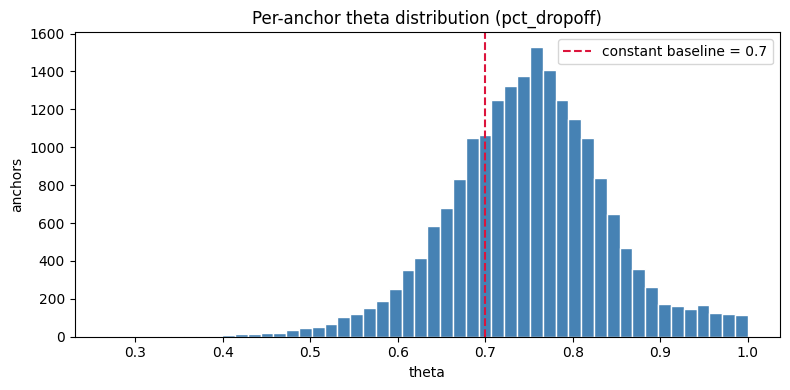

anchors with a threshold           : 20,005
stricter than 0.7 (theta > baseline) : 14,438 (72.2%)
looser  than 0.7 (theta < baseline) : 5,567 (27.8%)


In [12]:
thetas = np.array([t["theta"] for t in anchor_thresholds.values()])
n_stricter = int((thetas > CONSTANT_THETA_BASELINE).sum())   # higher bar than the fixed baseline
n_looser = int((thetas < CONSTANT_THETA_BASELINE).sum())
n_equal = int((thetas == CONSTANT_THETA_BASELINE).sum())

fig, ax = plt.subplots(figsize=(8, 4))
if len(thetas):
    ax.hist(thetas, bins=50, color="steelblue", edgecolor="white")
ax.axvline(CONSTANT_THETA_BASELINE, color="crimson", linestyle="--", linewidth=1.5,
           label=f"constant baseline = {CONSTANT_THETA_BASELINE}")
ax.set_title("Per-anchor theta distribution (pct_dropoff)")
ax.set_xlabel("theta"); ax.set_ylabel("anchors")
ax.legend()
plt.tight_layout(); plt.show()

print(f"anchors with a threshold           : {len(thetas):,}")
print(f"stricter than {CONSTANT_THETA_BASELINE} (theta > baseline) : {n_stricter:,} "
      f"({100 * n_stricter / max(len(thetas), 1):.1f}%)")
print(f"looser  than {CONSTANT_THETA_BASELINE} (theta < baseline) : {n_looser:,} "
      f"({100 * n_looser / max(len(thetas), 1):.1f}%)")
if n_equal:
    print(f"exactly {CONSTANT_THETA_BASELINE}                        : {n_equal:,}")

---
## 12. Transform filtered walks into human-readable format

In [13]:
readable_path = FILTER_DIR / "walk_sentences_readable.txt"
prev_anchor = None
with open(readable_path, "w") as f:
    for s in kept_sentences:
        if s["anchor_id"] != prev_anchor:
            if prev_anchor is not None:
                f.write("\n")
            prev_anchor = s["anchor_id"]
        f.write(f"[{s['anchor_id']}] " + " -> ".join(names(s["sentence"])) + "\n")

print(f"Saved {readable_path.name} ({len(kept_sentences):,} lines across "
      f"{len({s['anchor_id'] for s in kept_sentences}):,} anchors)")

Saved walk_sentences__pct_dropoff_readable.txt (75,605 lines across 16,056 anchors)
